# Analisis Shap
## Satisfacción del Cliente

In [3]:
import shap
import joblib
from joblib import dump, load
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
modelo = joblib.load("best_model_rl.pkl")
print("Modelo cargado correctamente")
print(type(modelo))

Modelo cargado correctamente
<class 'sklearn.linear_model._logistic.LogisticRegression'>


In [8]:
print(modelo)

LogisticRegression(C=0.004517754488006775, class_weight='balanced',
                   l1_ratio=None, max_iter=1000, penalty='l2',
                   random_state=2357, solver='saga')


In [7]:
# Verificar que el modelo ya fue entrenado
print("Coeficientes:", modelo.coef_)
print("Intercepto:", modelo.intercept_)

Coeficientes: [[-0.24414425 -0.03160369  0.19819019 -0.01573994 -0.01042543 -0.23973457
   0.00213957 -0.03782918  0.02668544 -0.07388111 -0.08436517  0.00509083
  -0.0296473  -0.03455999 -0.05438396 -0.17554256  0.06765331  0.12821449
  -0.02184372  0.01555558  0.01678426  0.02256127 -0.03619253 -0.0432682
  -0.03554356  0.11030647 -0.08234684 -0.0107991   0.12970242]]
Intercepto: [0.1180172]


In [10]:
# Tus datos (sin la variable objetivo)
X = pd.read_csv("backtest.csv")
X = X.drop(columns=["satisfecho"])  # si aplica

# ── Explainer para modelos lineales ───────────────────────
explainer = shap.LinearExplainer(modelo, X)
shap_values = explainer(X)

In [11]:
print(shap_values.shape)

(19590, 29)


## 1. Importance global  
para identificar las variables más influyentes.

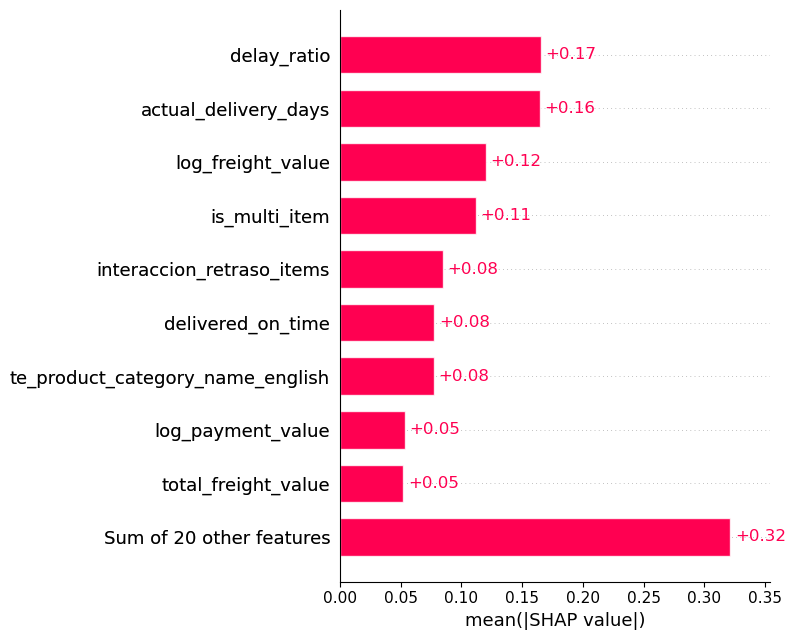

In [ ]:
# ── Bar plot (importancia global) ───────────────────────
plt.figure()
shap.plots.bar(shap_values, show=False)
plt.tight_layout()
plt.savefig("shap_bar.png", dpi=250)
plt.show()

El gráfico de importancia global basado en los valores SHAP permite identificar las variables que tienen mayor influencia promedio sobre las predicciones del modelo. Los resultados muestran que las características asociadas al desempeño logístico son las más relevantes, destacándose principalmente `delay_ratio` y `actual_delivery_days`, seguidas por `log_freight_value`, `is_multi_item` e `interaccion_retraso_items`. Estas variables presentan los mayores valores medios absolutos de SHAP, lo que indica que son las que generan los cambios más significativos en la probabilidad estimada de satisfacción del cliente, tambien se observa que variables relacionadas con el precio o el valor económico de la compra presentan una influencia relativamente menor en comparación con los factores logísticos.  
Este hallazgo sugiere que la experiencia de entrega tiene un peso más importante en la percepción del cliente que aspectos puramente monetarios. En consecuencia, la reducción de retrasos y la mejora en el cumplimiento de los plazos de entrega aparecen como los principales factores asociados a la satisfacción del cliente dentro del conjunto de datos analizado.

## 2. importancia + dirección del efecto.
   para responder:  

- cuáles son las variables importantes  
- cómo afectan  
- si valores altos o bajos incrementan la insatisfacción  

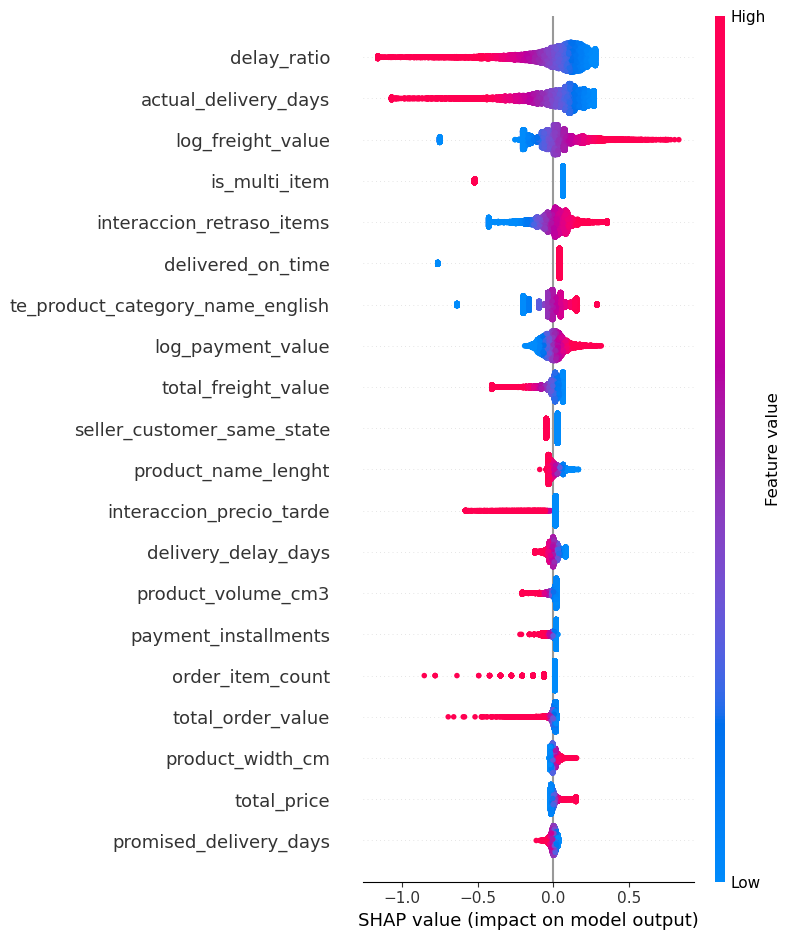

In [ ]:
# ── Summary plot (beeswarm) ──────────────────
plt.figure()
shap.summary_plot(shap_values, X, show=False)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=250)
plt.show()

El gráfico Summary Plot proporciona una visión detallada tanto de la importancia de las variables como de la dirección de su influencia sobre las predicciones del modelo. Cada punto representa una observación individual, mientras que su posición horizontal indica la contribución de la variable a la predicción y el color refleja la magnitud del valor de dicha característica. Las variables se encuentran ordenadas según su importancia global, coincidiendo con los resultados observados en el gráfico anterior.

Los patrones observados muestran que variables como `actual_delivery_days` y `delay_ratio` presentan una contribución importante en la disminución de la probabilidad de satisfacción cuando sus valores aumentan, resultado que también se encuentra respaldado por los coeficientes negativos de la regresión logística. De forma similar, variables relacionadas con pedidos más complejos, como `is_multi_item` o la participación de múltiples vendedores, tienden a asociarse con menores niveles de satisfacción. Por otro lado, la variable `delivered_on_time` presenta una contribución positiva hacia la satisfacción, confirmando que el cumplimiento de los tiempos prometidos constituye uno de los factores más relevantes para una experiencia favorable del cliente.


## explicación local de una predicción individual

Para algunos casos bien clasificados y mal clasificados.  
Esto suele ser lo más valioso para una presentación porque permite explicar una predicción individual paso a paso.

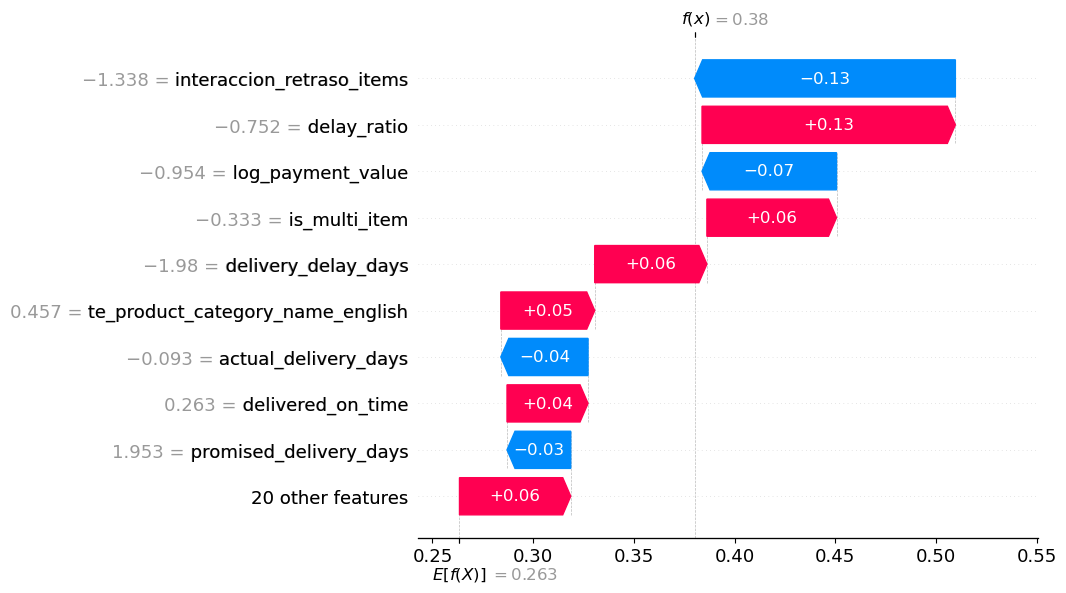

In [21]:
# ── Explicación individual (primera observación) ──────────
shap.plots.waterfall(shap_values[0])

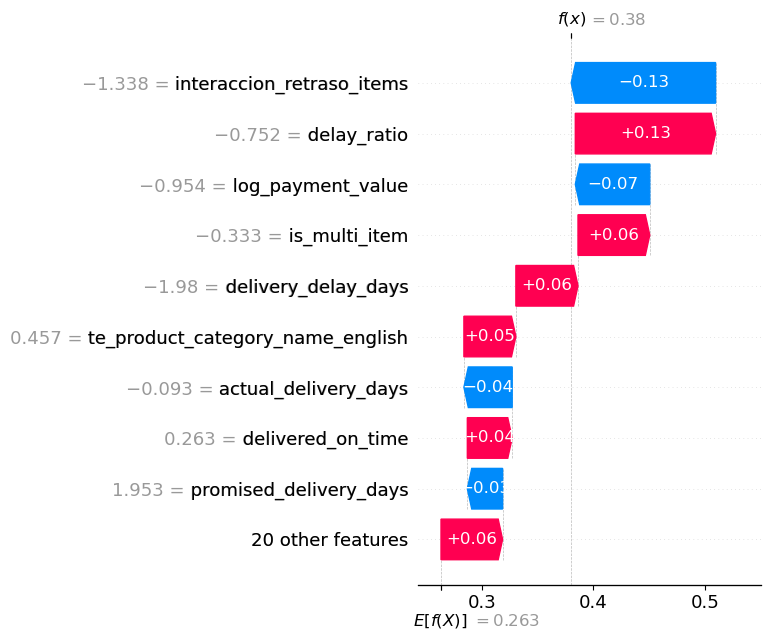

In [22]:
plt.figure()
shap.plots.waterfall(shap_values[0], show=False)
plt.tight_layout()
plt.savefig("shap_waterfall.png", dpi=250, bbox_inches="tight")
plt.show()

El gráfico Waterfall permite analizar de manera individual una predicción específica realizada por el modelo. La explicación parte de una probabilidad base de satisfacción correspondiente al promedio del conjunto de datos y muestra cómo cada característica del pedido contribuye a aumentar o disminuir dicha probabilidad hasta alcanzar la predicción final. De esta manera, el gráfico proporciona una explicación transparente del proceso de decisión del modelo para una observación concreta.

En el caso analizado, las variables relacionadas con el retraso de entrega y la complejidad logística presentan las contribuciones más relevantes sobre la predicción. Características como `delay_ratio`, `delivery_delay_days` e `is_multi_item` ejercen una influencia importante en el resultado final, mientras que otras variables contribuyen en sentido contrario reduciendo su impacto. Este comportamiento es consistente con los hallazgos obtenidos en los análisis globales, reforzando la evidencia de que los aspectos logísticos constituyen el principal factor determinante de la satisfacción o insatisfacción de los clientes en el conjunto de datos estudiado.

**Dependence plots**

Sobre las 5 variables más importantes para analizar relaciones específicas.

In [ ]:
# ── Dependence plots para las 5 features más importantes ──
importancia = np.abs(shap_values.values).mean(axis=0)
top_indices = np.argsort(importancia)[::-1][:5]  # top 5

print("Top 5 features más importantes:")
for i in top_indices:
    print(f"  {X.columns[i]}: {importancia[i]:.4f}")

# tema del grafico
# plt.style.use('bmh') # seaborn-v0_8-whitegrid, bmh
# Generar un dependence plot por cada una
for i in top_indices:
    nombre = X.columns[i]
    plt.figure()
    shap.plots.scatter(shap_values[:, nombre], show=False)
    plt.title(f"Dependencia: {nombre}", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"shap_dependencia_{nombre}_v1.png",
                dpi=200, bbox_inches="tight")
    plt.close()
    plt.show()

In [36]:
import matplotlib.pyplot as plt

# --- PASO 1: ELEGIR UN TEMA (Descomenta el que te guste) ---
# Estilo limpio con cuadrícula gris (muy legible)
# plt.style.use('seaborn-v0_8-whitegrid')
# Estilo clásico de R (muy popular en ciencia de datos)
# plt.style.use('ggplot')
# Estilo oscuro (bueno para presentaciones)
# plt.style.use('dark_background')
# Estilo minimalista
plt.style.use('bmh')

for i in top_indices:
    nombre = X.columns[i]

    plt.figure(figsize=(8, 5))  # Añadí un tamaño base un poco más grande

    # --- PASO 2: PERSONALIZAR COLORES ---
    # 'cmap' controla el gradiente de color de los puntos.
    # Opciones comunes: 'coolwarm' (azul a rojo), 'viridis' (por defecto), 'plasma', 'jet'.
    shap.plots.scatter(shap_values[:, nombre], show=False, cmap="coolwarm")

    # Personalización extra del título
    plt.title(f"Dependencia SHAP: {nombre}", fontsize=14, fontweight='bold')

    # Forzar que el fondo de la figura sea blanco (útil si el tema no lo hace)
    # fig = plt.gcf()
    # fig.patch.set_facecolor('white')

    plt.tight_layout()
    plt.savefig(f"shap_dependencia_{nombre}_v3.png",
                dpi=300, bbox_inches="tight")
    plt.close()  # Es buena práctica usar plt.close() en bucles para liberar memoria
    # plt.show() # Si lo estás corriendo en Jupyter, puedes usar show()

**Conclusión**

El análisis de interpretabilidad mediante SHAP mostró que las variables relacionadas con el desempeño logístico son las que ejercen mayor influencia sobre las predicciones del modelo. En particular, los días reales de entrega (actual_delivery_days) y el índice de retraso relativo (delay_ratio) presentaron las mayores contribuciones absolutas, evidenciando que el cumplimiento de los tiempos de entrega constituye el principal determinante de la satisfacción del cliente.

La interpretación conjunta de los valores SHAP y de los coeficientes del modelo de regresión logística indica que incrementos en los tiempos de entrega y en los niveles de retraso reducen significativamente la probabilidad de satisfacción. Asimismo, los pedidos que involucran múltiples artículos o múltiples vendedores presentan una mayor propensión a generar experiencias negativas, probablemente debido a una mayor complejidad logística.

Por otro lado, la variable delivered_on_time mostró una asociación positiva con la satisfacción, confirmando la importancia del cumplimiento de las fechas comprometidas. En conjunto, los resultados sugieren que las mejoras en la gestión logística y la reducción de retrasos representan las acciones con mayor potencial para incrementar la satisfacción de los clientes dentro de la plataforma de comercio electrónico analizada.


In [27]:
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coef': modelo.coef_[0]
})

print(coef_df.sort_values('coef', ascending=False))

                             feature      coef
2                  delivered_on_time  0.198190
28  te_product_category_name_english  0.129702
17                 log_freight_value  0.128214
25         interaccion_retraso_items  0.110306
16                 log_payment_value  0.067653
8                        total_price  0.026685
21                  product_width_cm  0.022561
20                 product_height_cm  0.016784
19                 product_length_cm  0.015556
11                     freight_ratio  0.005091
6                 purchase_dayofweek  0.002140
4                dispatch_time_hours -0.010425
27         interaccion_entrega_flete -0.010799
3             promised_delivery_days -0.015740
18                  product_weight_g -0.021844
12              payment_installments -0.029647
1                delivery_delay_days -0.031604
13                 total_order_value -0.034560
24        seller_customer_same_state -0.035544
22               product_name_lenght -0.036193
7            

# Lift chart

In [38]:
y_score = modelo.predict_proba(X)[:, 0]

In [42]:
import pandas as pd
import numpy as np

df = pd.read_csv('y_backtest.csv')
y = df.iloc[:, 0]
df_lift = pd.DataFrame({
    "y_true": y,
    "score": y_score
})

# ordenar de mayor riesgo a menor riesgo
df_lift = df_lift.sort_values(
    "score",
    ascending=False
).reset_index(drop=True)

# deciles
df_lift["decil"] = pd.qcut(
    df_lift.index,
    q=10,
    labels=False
) + 1

In [47]:
df_lift.nunique()

y_true        2
score     19590
decil        10
dtype: int64

In [43]:
# clase objetivo = insatisfecho
target_rate = (df_lift["y_true"] == 0).mean()

lift_table = (
    df_lift
    .groupby("decil")
    .apply(lambda x: pd.Series({
        "clientes": len(x),
        "insatisfechos": (x["y_true"] == 0).sum(),
        "tasa": (x["y_true"] == 0).mean()
    }))
    .reset_index()
)

lift_table["lift"] = (
    lift_table["tasa"] /
    target_rate
)

print(lift_table)

   decil  clientes  insatisfechos      tasa      lift
0      1    1959.0         1001.0  0.510975  2.774390
1      2    1959.0          515.0  0.262889  1.427384
2      3    1959.0          394.0  0.201123  1.092018
3      4    1959.0          310.0  0.158244  0.859202
4      5    1959.0          258.0  0.131700  0.715078
5      6    1959.0          253.0  0.129148  0.701220
6      7    1959.0          256.0  0.130679  0.709534
7      8    1959.0          214.0  0.109239  0.593126
8      9    1959.0          220.0  0.112302  0.609756
9     10    1959.0          187.0  0.095457  0.518293


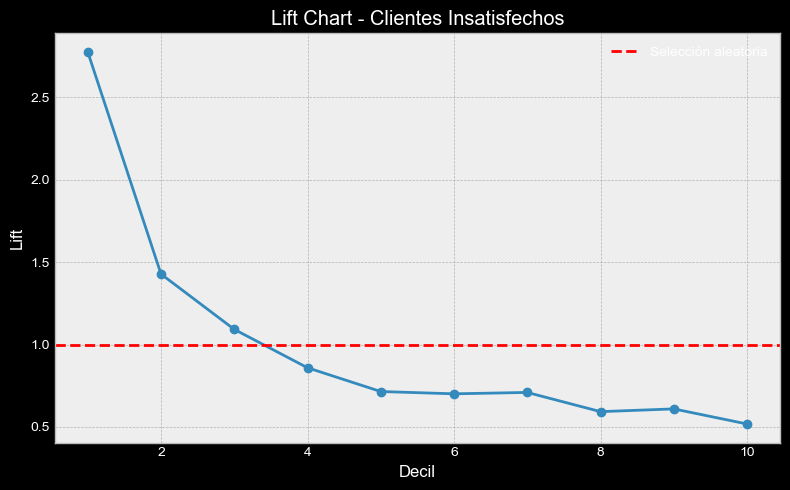

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    lift_table["decil"],
    lift_table["lift"],
    marker="o"
)

plt.axhline(
    1,
    linestyle="--",
    color="red",
    label="Selección aleatoria"
)

plt.xlabel("Decil")
plt.ylabel("Lift")
plt.title("Lift Chart - Clientes Insatisfechos")
plt.legend()

plt.tight_layout()
plt.show()

### Interpretación del Lift obtenido

La tasa global de insatisfacción de tu dataset es aproximadamente:

```python
1001+515+394+310+258+253+256+214+220+187
----------------------------------------- ≈ 0.184
19590
```

≈ **18.4%**

Ahora observa el primer decil:

```text
Lift = 2.77
Tasa de insatisfechos = 51.1%
```

Interpretación:

> El 10% de clientes que el modelo considera con mayor riesgo contiene aproximadamente 2.8 veces más clientes insatisfechos que una selección aleatoria.

Desde una perspectiva de negocio es un resultado bastante bueno.

---

## ROC Curve

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probabilidad de insatisfacción (clase 0)
y_score = modelo.predict_proba(X_test)[:, 0]

# Convertimos para que la clase positiva sea la insatisfacción
y_binary = (y_test == 0).astype(int)

fpr, tpr, _ = roc_curve(y_binary, y_score)
auc = roc_auc_score(y_binary, y_score)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1], [0,1], '--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Clientes Insatisfechos')
plt.legend()

plt.tight_layout()
plt.show()

Interpretación

Podrás escribir algo parecido a:

> La curva ROC muestra la capacidad del modelo para discriminar entre clientes satisfechos e insatisfechos para distintos umbrales de decisión. El valor AUC obtenido indica la probabilidad de que el modelo asigne una puntuación de riesgo superior a un cliente insatisfecho respecto a un cliente satisfecho seleccionado aleatoriamente. Cuanto más cercana se encuentre la curva al vértice superior izquierdo, mejor es el desempeño discriminativo del modelo.

--- 

## Precision-Recall Curve

In [ ]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

precision, recall, _ = precision_recall_curve(
    y_binary,
    y_score
)

ap = average_precision_score(
    y_binary,
    y_score
)

plt.figure(figsize=(7,5))

plt.plot(
    recall,
    precision,
    label=f'AP = {ap:.3f}'
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Clientes Insatisfechos')
plt.legend()

plt.tight_layout()
plt.show()

Interpretación

> La curva Precision-Recall evalúa la capacidad del modelo para identificar correctamente clientes insatisfechos manteniendo un equilibrio entre precisión y cobertura. Esta representación resulta especialmente útil en problemas con desbalance de clases, ya que se enfoca exclusivamente en el comportamiento de la clase objetivo. Un área bajo la curva elevada indica que el modelo logra recuperar una proporción importante de clientes insatisfechos sin generar un número excesivo de falsas alarmas.

---

## Cumulative Gains Chart

_Este es probablemente el gráfico más interesante para negocio._

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "y_true": y_binary,
    "score": y_score
})

df = df.sort_values(
    "score",
    ascending=False
)

df["cum_target"] = df["y_true"].cumsum()

total_target = df["y_true"].sum()

df["gain"] = (
    df["cum_target"] /
    total_target
)

df["population"] = (
    np.arange(1, len(df)+1) /
    len(df)
)

plt.figure(figsize=(7,5))

plt.plot(
    df["population"],
    df["gain"],
    label="Modelo"
)

plt.plot(
    [0,1],
    [0,1],
    "--",
    label="Aleatorio"
)

plt.xlabel("Porcentaje de clientes")
plt.ylabel("Porcentaje acumulado de insatisfechos")
plt.title("Cumulative Gains Chart")
plt.legend()

plt.tight_layout()
plt.show()

Interpretación

Este gráfico responde directamente preguntas como:

> Si analizamos únicamente el 20% de los clientes que el modelo considera más riesgosos, ¿qué porcentaje de todos los clientes insatisfechos logramos capturar?

Por ejemplo, si el gráfico muestra:

``20% población → 60% insatisfechos``

la interpretación sería:

> Interviniendo únicamente sobre el 20% de los clientes identificados como de mayor riesgo es posible detectar aproximadamente el 60% de todos los clientes insatisfechos.

Ese tipo de resultado suele ser muy atractivo para una presentación ejecutiva porque traduce el rendimiento del modelo a impacto operativo.

De hecho, con la tabla de Lift que mostraste ya podemos anticipar que tu Gains Chart debería verse bastante bien, porque el primer decil concentra 1001 de los 3608 clientes insatisfechos (≈27.7%), mientras que solo representa el 10% de la población. Eso indica una capacidad de ranking claramente superior al azar.